## First of all Install all the libraries

In [7]:
! pip install numpy==1.26.4 scipy==1.13.1 seaborn==0.13.2 matplotlib scikit-learn tensorflow plotly statsmodels --force-reinstall -q

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'e:\\time serise noyase data analysis\\time_serise_noice_dataset_analysis\\.venv\\lib\\site-packages\\81d243bd2c585b0f4821__mypyc.cp311-win_amd64.pyd'
Check the permissions.


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import all libraries 

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, mean_squared_error, mean_absolute_error)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression

import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print("All good!")
print(f"   NumPy      : {np.__version__}")
print(f"   TensorFlow : {tf.__version__}")
print(f"   Pandas     : {pd.__version__}")

All good!
   NumPy      : 2.4.6
   TensorFlow : 2.21.0
   Pandas     : 3.0.3


## Load dataset

In [9]:
df = pd.read_csv(r'E:\Time serise noyase data analysis\Time_serise_Noice_dataset_analysis\data\raw\predictive_maintenance_dataset.csv')

In [11]:
df.head(5)

,timestamp,machine_id,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,label
0,2024-07-01 08:00:00,M01,0.822,0.645,66.85,13.04,0.196,0.033,0.000,0
1,2024-07-01 08:01:00,M01,1.398,0.834,76.20,15.08,0.345,0.132,0.001,1
2,2024-07-01 08:02:00,M01,0.856,0.590,67.03,12.30,0.187,0.017,0.002,0
3,2024-07-01 08:03:00,M01,0.793,0.544,65.04,11.69,0.196,-0.060,0.003,0
4,2024-07-01 08:04:00,M01,1.279,0.721,78.19,14.84,0.330,-0.115,0.004,1


## 1. Dataset Overview


First, we inspect:

- Number of rows and columns
- Column names and data types
- Memory usage
- A quick peek at the first few rows

In [14]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [15]:
df.head(5)

,timestamp,machine_id,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,label
0,2024-07-01 08:00:00,M01,0.822,0.645,66.85,13.04,0.196,0.033,0.000,0
1,2024-07-01 08:01:00,M01,1.398,0.834,76.20,15.08,0.345,0.132,0.001,1
2,2024-07-01 08:02:00,M01,0.856,0.590,67.03,12.30,0.187,0.017,0.002,0
3,2024-07-01 08:03:00,M01,0.793,0.544,65.04,11.69,0.196,-0.060,0.003,0
4,2024-07-01 08:04:00,M01,1.279,0.721,78.19,14.84,0.330,-0.115,0.004,1


In [20]:
print(f"  Shape          : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Time Range     : {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"  Machines       : {sorted(df['machine_id'].unique())}")

  Shape          : 1800 rows × 10 columns
  Time Range     : 2024-07-01 08:00:00 → 2024-07-01 17:59:00
  Machines       : ['M01', 'M02', 'M03']


#### for this analysis i find.
1. Hear is a total 1800 rows and 10 columns.  
2. this dataset have only 1 day of data.
3. that is 2024-07-01 from 8:00 AM to 5:59 PM. 
4. Once reading every minute, 10 hours in total. 
5. total 3 machines(M01, M02, M03) is used for this dataset. 
6. and 600 readings each.

In [21]:
print(f"  Missing Values : {df.isnull().sum().sum()}")

  Missing Values : 0


7. Ther is no missing value. 

In [22]:
print(df.head().to_string())

            timestamp machine_id  vibration  acoustic  temperature  current  IMF_1  IMF_2  IMF_3  label
0 2024-07-01 08:00:00        M01      0.822     0.645        66.85    13.04  0.196  0.033  0.000      0
1 2024-07-01 08:01:00        M01      1.398     0.834        76.20    15.08  0.345  0.132  0.001      1
2 2024-07-01 08:02:00        M01      0.856     0.590        67.03    12.30  0.187  0.017  0.002      0
3 2024-07-01 08:03:00        M01      0.793     0.544        65.04    11.69  0.196 -0.060  0.003      0
4 2024-07-01 08:04:00        M01      1.279     0.721        78.19    14.84  0.330 -0.115  0.004      1


In [24]:
print("\nColumns:\n", df.columns.tolist())


Columns:
 ['timestamp', 'machine_id', 'vibration', 'acoustic', 'temperature', 'current', 'IMF_1', 'IMF_2', 'IMF_3', 'label']


In [23]:
print(df.dtypes)

timestamp      datetime64[us]
machine_id                str
vibration             float64
acoustic              float64
temperature           float64
current               float64
IMF_1                 float64
IMF_2                 float64
IMF_3                 float64
label                   int64
dtype: object


In [26]:
for val, count in df['label'].value_counts().items():
    status = "Healthy" if val == 0 else "Faulty"
    print(f"  {val} ({status}) → {count} rows ({count/len(df)*100:.1f}%)")

  0 (Healthy) → 1598 rows (88.8%)
  1 (Faulty) → 202 rows (11.2%)


8. Label(most importent)

- Healthy (0) → 1598 rows → 88.8%
- Faulty (1) → 202 rows → 11.2%

``IT means this is an imbalanced dataset. There is very little faulty data. So I have to handle this when training the model, otherwise the model will always say "Healthy" and show high accuracy but it will not actually work.``

In [27]:
print(df.describe().round(3).to_string())

                 timestamp  vibration  acoustic  temperature   current     IMF_1     IMF_2     IMF_3     label
count                 1800   1800.000  1800.000     1800.000  1800.000  1800.000  1800.000  1800.000  1800.000
mean   2024-07-01 12:59:30      0.843     0.634       66.356    12.329     0.169     0.000     0.001     0.112
min    2024-07-01 08:00:00      0.645     0.430       58.360    10.290     0.073    -0.180    -0.050     0.000
25%    2024-07-01 10:29:45      0.769     0.572       63.730    11.700     0.123    -0.058    -0.037     0.000
50%    2024-07-01 12:59:30      0.805     0.609       65.355    12.080     0.166    -0.001     0.004     0.000
75%    2024-07-01 15:29:15      0.851     0.651       66.990    12.480     0.207     0.059     0.037     0.000
max    2024-07-01 17:59:00      1.405     1.083       85.160    16.940     0.393     0.187     0.050     1.000
std                    NaN      0.137     0.108        4.448     1.095     0.057     0.073     0.036     0.316


9. Sensor Ranges (from Descriptive Statistics)

Sensor      ->      Min        ->       Max 
-------------------------------------------------------
vibration      ->      0.645       ->       1.405    
temperature     ->      ~57°C        ->      85°C
current      ->      ~10A        ->       16.9A
IMF_1/2/3      ->        low      ->       low    

``In Row 1, vibration = 1.398, temperature = 76.20, label = 1 — that is, the fault occurs only when vibration and temperature are high. This is what my model will learn.``

## Step 2: Outlier & Noise Detection

Before modeling, we must identify:
- **Outliers**: Extreme sensor values beyond normal operating range
- **Noise**: Random spikes that don't represent real patterns

### Methods Used:
1. **IQR Method** — values beyond Q1-1.5×IQR or Q3+1.5×IQR are outliers
2. **Z-Score Method** — values beyond ±3 standard deviations are outliers
3. **Visual Boxplot** — to see distribution and outlier points

In [30]:
sensor_cols = ['vibration', 'acoustic', 'temperature', 'current', 'IMF_1', 'IMF_2', 'IMF_3']

### OUTLIER DETECTION — IQR METHOD

In [31]:
outlier_summary = []

for col in sensor_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        'Sensor': col,
        'Lower Bound': round(lower, 3),
        'Upper Bound': round(upper, 3),
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df) * 100, 2)
    })
    print(f"  {col:<12} | Bounds: [{lower:.3f}, {upper:.3f}] | Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

  vibration    | Bounds: [0.646, 0.974] | Outliers: 203 (11.3%)
  acoustic     | Bounds: [0.453, 0.770] | Outliers: 192 (10.7%)
  temperature  | Bounds: [58.840, 71.880] | Outliers: 205 (11.4%)
  current      | Bounds: [10.530, 13.650] | Outliers: 202 (11.2%)
  IMF_1        | Bounds: [-0.003, 0.333] | Outliers: 23 (1.3%)
  IMF_2        | Bounds: [-0.233, 0.234] | Outliers: 0 (0.0%)
  IMF_3        | Bounds: [-0.148, 0.148] | Outliers: 0 (0.0%)


#### The IQR method shows ~11% outliers in vibration, acoustic, temperature, current. And our faulty label is exactly 11.2%! This means that these "outliers" are not actually outliers, they are real fault signals! If i delete them, the model will not be able to learn.

### Decision
- The ~11% outliers in vibration, acoustic, temperature, and current
- are NOT random noise — they are genuine fault signatures.
- **We must KEEP them.**
- Only IMF_1 has minor noise (1.3%) which we will cap using
- the Winsorization technique.

### OUTLIER DETECTION — Z-SCORE METHOD

In [32]:
from scipy import stats

for col in sensor_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    outliers_z = df[z_scores > 3]
    print(f"  {col:<12} | Z>3 Outliers: {len(outliers_z)} ({len(outliers_z)/len(df)*100:.1f}%)")

  vibration    | Z>3 Outliers: 51 (2.8%)
  acoustic     | Z>3 Outliers: 48 (2.7%)
  temperature  | Z>3 Outliers: 28 (1.6%)
  current      | Z>3 Outliers: 40 (2.2%)
  IMF_1        | Z>3 Outliers: 19 (1.1%)
  IMF_2        | Z>3 Outliers: 0 (0.0%)
  IMF_3        | Z>3 Outliers: 0 (0.0%)


#### Boxplot Visualization

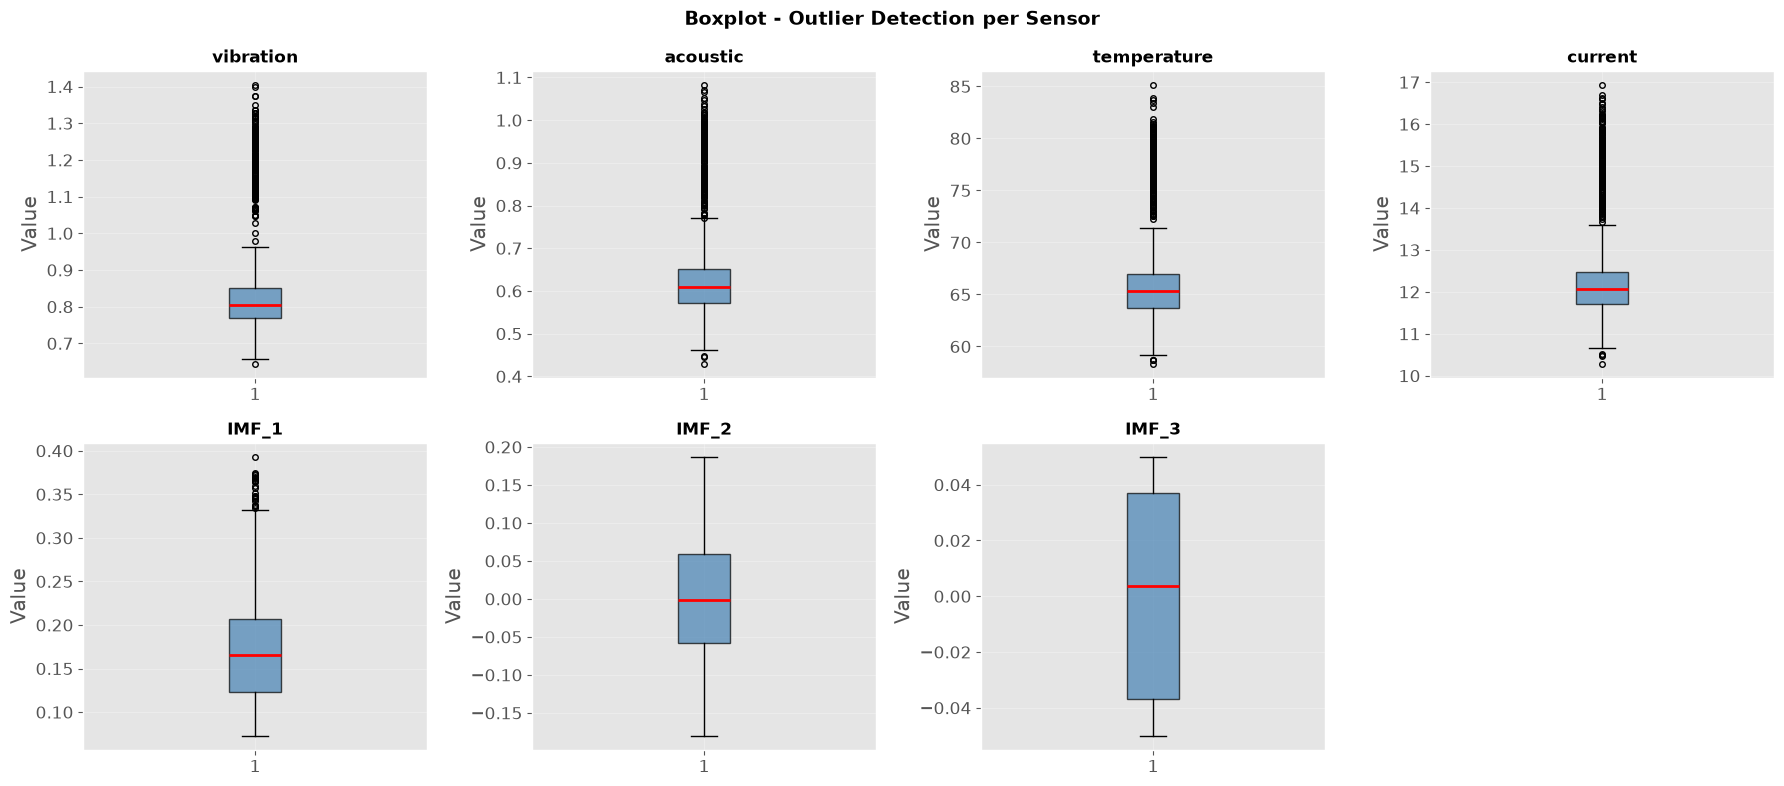

In [33]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='orange', markersize=4))
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_visible(False)  # last subplot hide
fig.suptitle('Boxplot - Outlier Detection per Sensor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Outlier Handle inly do IMF_1 cap

In [35]:
from scipy.stats.mstats import winsorize

df_clean = df.copy()

In [36]:
df_clean['IMF_1'] = winsorize(df_clean['IMF_1'], limits=[0.013, 0.013])

In [37]:
df_clean.head(5)

,timestamp,machine_id,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,label
0,2024-07-01 08:00:00,M01,0.822,0.645,66.85,13.04,0.196,0.033,0.000,0
1,2024-07-01 08:01:00,M01,1.398,0.834,76.20,15.08,0.332,0.132,0.001,1
2,2024-07-01 08:02:00,M01,0.856,0.590,67.03,12.30,0.187,0.017,0.002,0
3,2024-07-01 08:03:00,M01,0.793,0.544,65.04,11.69,0.196,-0.060,0.003,0
4,2024-07-01 08:04:00,M01,1.279,0.721,78.19,14.84,0.330,-0.115,0.004,1


In [40]:
print("IMF_1 - Before vs After Winsorization:")
print(f"  Before --> Min: {df['IMF_1'].min():.4f} | Max: {df['IMF_1'].max():.4f}")
print(f"  After  --> Min: {df_clean['IMF_1'].min():.4f} | Max: {df_clean['IMF_1'].max():.4f}")

IMF_1 - Before vs After Winsorization:
  Before --> Min: 0.0730 | Max: 0.3930
  After  --> Min: 0.0800 | Max: 0.3320


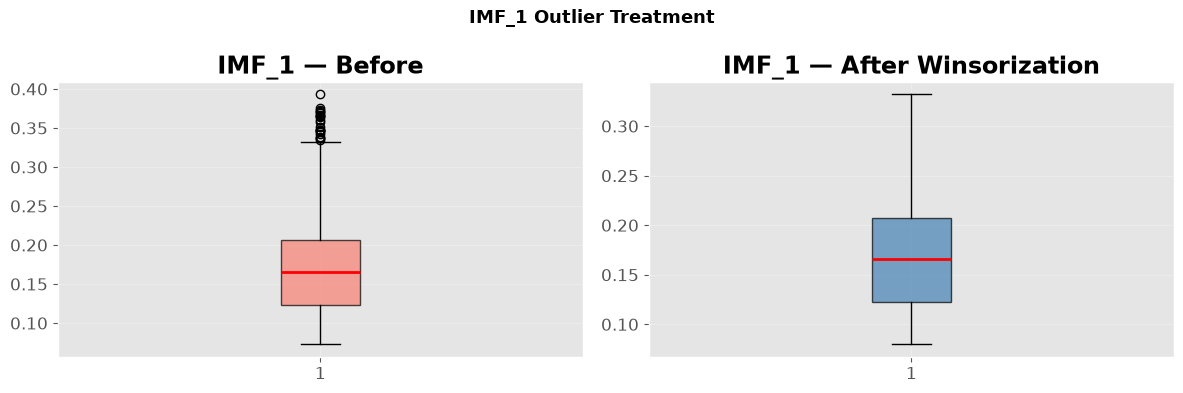

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['IMF_1'], patch_artist=True,
                boxprops=dict(facecolor='salmon', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('IMF_1 — Before', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df_clean['IMF_1'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('IMF_1 — After Winsorization', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('IMF_1 Outlier Treatment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Step 3: Exploratory Data Analysis (EDA)

### Goals:
1. Sensor trends over time 
2. Healthy vs Faulty sensor behavior compare 
3. Feature correlation 
4. Label distribution visualize

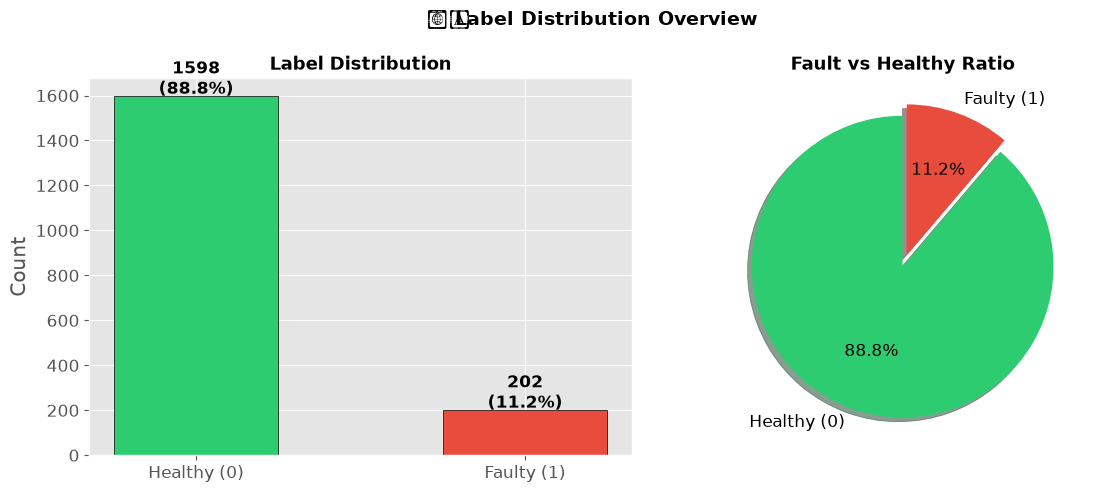

In [42]:
# Label Distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
counts = df_clean['label'].value_counts().sort_index()
axes[0].bar(['Healthy (0)', 'Faulty (1)'], counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, f'{v}\n({v/len(df_clean)*100:.1f}%)', 
                 ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Healthy (0)', 'Faulty (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            explode=(0, 0.08), shadow=True)
axes[1].set_title('Fault vs Healthy Ratio', fontsize=13, fontweight='bold')

plt.suptitle('🏷️ Label Distribution Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA Findings

#### Label Distribution

- The dataset is clearly imbalanced - Healthy 88.8%, Faulty only 11.2%
- This must be handled in model training

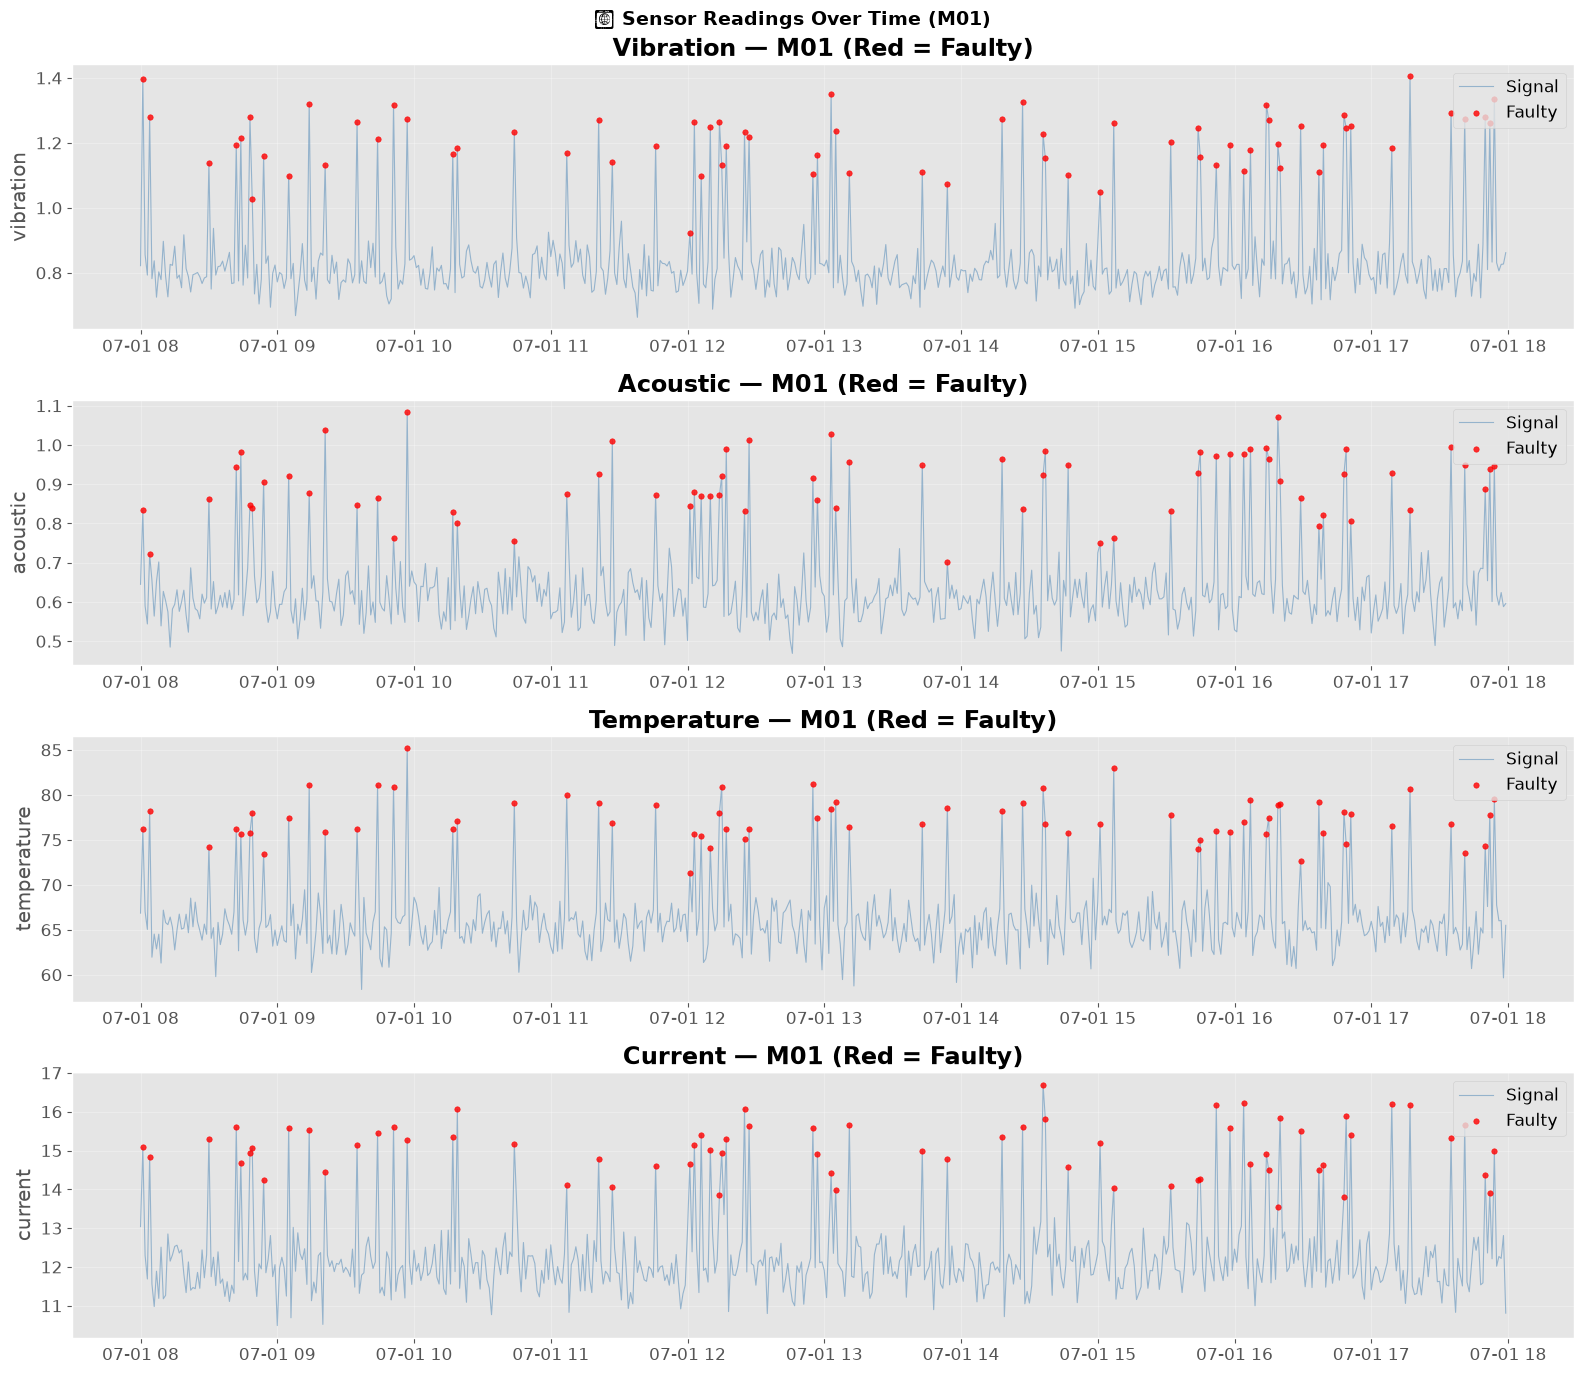

In [43]:
# Sensor trend over time — Healthy vs Faulty highlighted

sensor_cols = ['vibration', 'acoustic', 'temperature', 'current']

fig, axes = plt.subplots(4, 1, figsize=(16, 14))

for i, col in enumerate(sensor_cols):
    # M01 data
    m01 = df_clean[df_clean['machine_id'] == 'M01'].copy()
    
    healthy = m01[m01['label'] == 0]
    faulty  = m01[m01['label'] == 1]
    
    axes[i].plot(m01['timestamp'], m01[col], 
                 color='steelblue', alpha=0.5, linewidth=0.8, label='Signal')
    axes[i].scatter(faulty['timestamp'], faulty[col], 
                    color='red', s=15, zorder=5, label='Faulty', alpha=0.8)
    axes[i].set_title(f'{col.capitalize()} — M01 (Red = Faulty)', fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('📈 Sensor Readings Over Time (M01)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Sensor Time Series (M01):

### The same pattern is seen on all 4 sensors:

- During normal times, the signal is low and stable
- When there is a fault, the spike suddenly goes up (red dot)
- The faults are not random - scattered throughout the day but clearly distinguishable
- This proves that it is possible to predict faults using sensor data



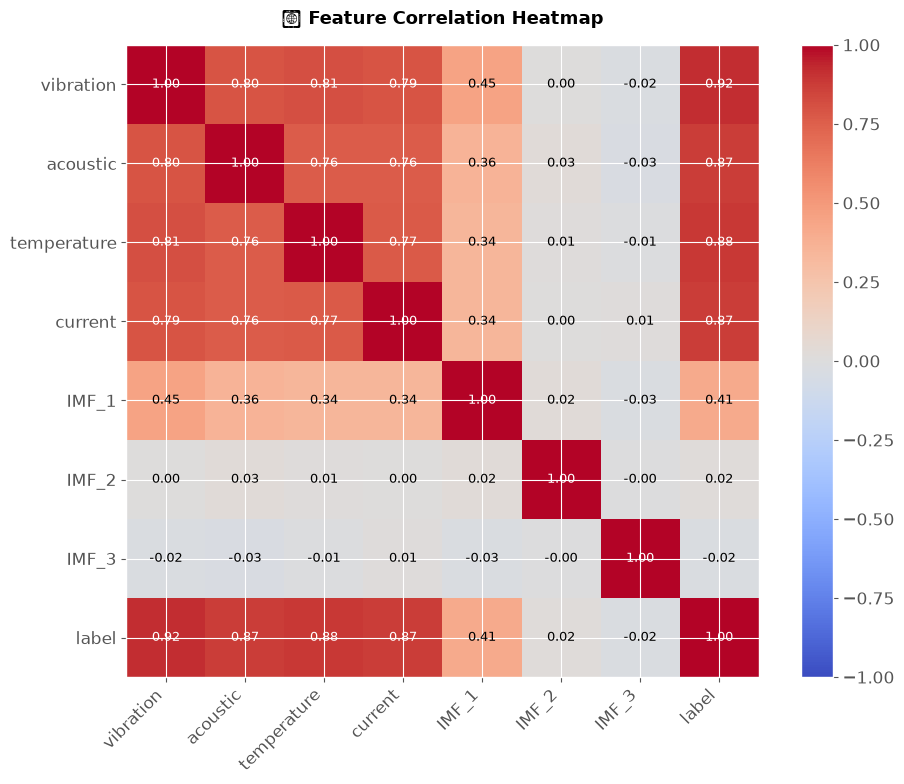

In [48]:
# Correlation Heatmap

numeric_cols = ['vibration', 'acoustic', 'temperature', 'current', 
                'IMF_1', 'IMF_2', 'IMF_3', 'label']

corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', 
                ha='center', va='center', fontsize=9,
                color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')

ax.set_title('🔥 Feature Correlation Heatmap', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Vibration, temperature, acoustic, current - these 4 are the main features of fault detection. IMF_2 and IMF_3 are less important.

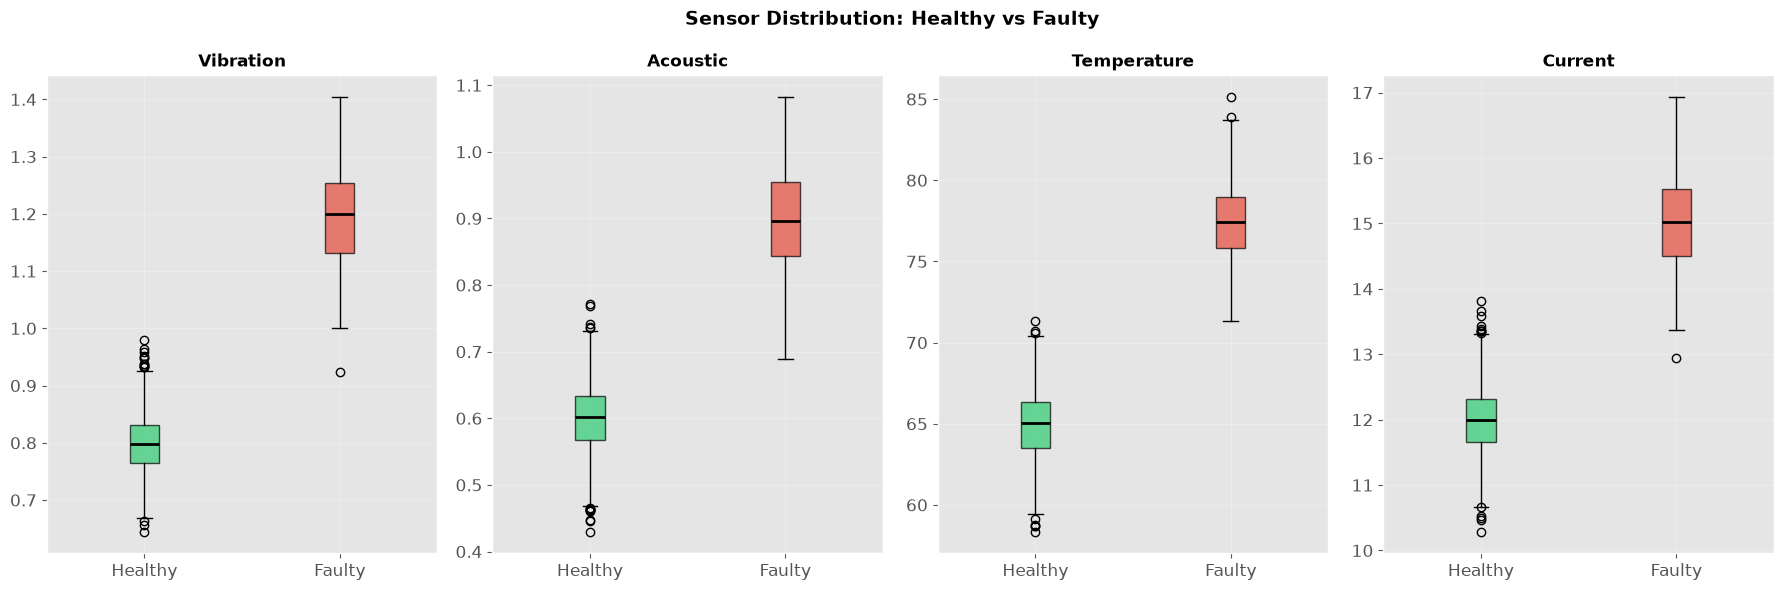

In [47]:
# Sensor distribution — Healthy vs Faulty comparison

sensor_cols = ['vibration', 'acoustic', 'temperature', 'current']

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, col in enumerate(sensor_cols):
    healthy_data = df_clean[df_clean['label'] == 0][col]
    faulty_data  = df_clean[df_clean['label'] == 1][col]
    
    bp = axes[i].boxplot([healthy_data, faulty_data],
                         tick_labels=['Healthy', 'Faulty'],  # ← fixed
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#e74c3c')
    bp['boxes'][1].set_alpha(0.7)
    
    axes[i].set_title(f'{col.capitalize()}', fontweight='bold', fontsize=12)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Sensor Distribution: Healthy vs Faulty', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### There is almost no overlap between the two groups - this is excellent for the model!

### EDA Summary - Decision for next step

1. I will keep features: vibration, acoustic, temperature, current, IMF_1
2. I will keep IMF_2, IMF_3 but with low priority
3. I will use class_weight='balanced' to handle unbalanced data
4. The model will clearly work because the sensor values ​​of the two classes are very different

===============================================================================================

##  Feature Engineering

### Why Feature Engineering?
Raw sensor readings alone may not capture the full pattern.
We need to extract additional time-based features to help the model
understand trends, momentum, and signal behavior over time.

### Techniques Used:
1. **Rolling Mean (window=5)** - short-term average trend
2. **Rolling Std (window=5)** - local volatility/noise level
3. **Lag Features (lag=1)** - previous reading as a feature
4. **Time Features** - hour of day extracted from timestamp
5. **Machine ID Encoding** - convert M01/M02/M03 to numbers

In [49]:
df_feat = df_clean.copy()
df_feat = df_feat.sort_values(['machine_id', 'timestamp']).reset_index(drop=True)

sensor_cols = ['vibration', 'acoustic', 'temperature', 'current', 'IMF_1']

In [51]:
df_feat.head(5)

,timestamp,machine_id,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,label,vibration_roll_mean,vibration_roll_std
0,2024-07-01 08:00:00,M01,0.822,0.645,66.85,13.04,0.196,0.033,0.000,0,0.822000,0.000000
1,2024-07-01 08:01:00,M01,1.398,0.834,76.20,15.08,0.332,0.132,0.001,1,1.110000,0.407294
2,2024-07-01 08:02:00,M01,0.856,0.590,67.03,12.30,0.187,0.017,0.002,0,1.025333,0.323186
3,2024-07-01 08:03:00,M01,0.793,0.544,65.04,11.69,0.196,-0.060,0.003,0,0.967250,0.288319
4,2024-07-01 08:04:00,M01,1.279,0.721,78.19,14.84,0.330,-0.115,0.004,1,1.029600,0.285978


In [52]:
for machine in df_feat['machine_id'].unique():
    mask = df_feat['machine_id'] == machine

    for col in sensor_cols:
        # Rolling Mean (window=5)
        df_feat.loc[mask, f'{col}_roll_mean'] = (
            df_feat.loc[mask, col].rolling(window=5, min_periods=1).mean()
        )
        # Rolling Std (window=5)
        df_feat.loc[mask, f'{col}_roll_std'] = (
            df_feat.loc[mask, col].rolling(window=5, min_periods=1).std().fillna(0)
        )
        # Lag Feature — fixed for pandas 3.x
        df_feat.loc[mask, f'{col}_lag1'] = (
            df_feat.loc[mask, col].shift(1).bfill()
        )

In [53]:
df_feat['hour'] = df_feat['timestamp'].dt.hour

In [54]:
machine_map = {'M01': 0, 'M02': 1, 'M03': 2}
df_feat['machine_enc'] = df_feat['machine_id'].map(machine_map)

In [55]:
print(f"Original features  : 10")
print(f"New features added : {len(df_feat.columns) - 10}")
print(f"Total features     : {len(df_feat.columns)}")
print(f"\nAll columns:")
for col in df_feat.columns:
    print(f"  → {col}")

Original features  : 10
New features added : 17
Total features     : 27

All columns:
  → timestamp
  → machine_id
  → vibration
  → acoustic
  → temperature
  → current
  → IMF_1
  → IMF_2
  → IMF_3
  → label
  → vibration_roll_mean
  → vibration_roll_std
  → vibration_lag1
  → acoustic_roll_mean
  → acoustic_roll_std
  → acoustic_lag1
  → temperature_roll_mean
  → temperature_roll_std
  → temperature_lag1
  → current_roll_mean
  → current_roll_std
  → current_lag1
  → IMF_1_roll_mean
  → IMF_1_roll_std
  → IMF_1_lag1
  → hour
  → machine_enc


In [56]:
print(f"   df_feat shape: {df_feat.shape}")

   df_feat shape: (1800, 27)


In [57]:
# Define final feature set for modeling

# Classification features (fault detection)
clf_features = [
    'vibration', 'acoustic', 'temperature', 'current', 'IMF_1',
    'vibration_roll_mean', 'vibration_roll_std', 'vibration_lag1',
    'acoustic_roll_mean', 'acoustic_roll_std', 'acoustic_lag1',
    'temperature_roll_mean', 'temperature_roll_std', 'temperature_lag1',
    'current_roll_mean', 'current_roll_std', 'current_lag1',
    'IMF_1_roll_mean', 'IMF_1_roll_std', 'IMF_1_lag1',
    'hour', 'machine_enc'
]

# Regression features (temperature & vibration forecast)
reg_features = [
    'vibration', 'acoustic', 'current', 'IMF_1',
    'vibration_roll_mean', 'vibration_roll_std', 'vibration_lag1',
    'acoustic_roll_mean', 'temperature_roll_mean', 'temperature_lag1',
    'current_roll_mean', 'hour', 'machine_enc'
]

print("Classification Features:", len(clf_features))
print("Regression Features    :", len(reg_features))

Classification Features: 22
Regression Features    : 13


========================================================================================================

## Model Training — Fault Detection (Classification)

### Models:
1. **Logistic Regression** — Simple baseline model
2. **Random Forest** — Advanced ensemble model

### Strategy:
- **TimeSeriesSplit** — Random split cannot be done on time-series data,
because predicting the past with future data would be cheating
- **class_weight='balanced'** — to handle unbalanced data
- **StandardScaler** — to normalize features

### Data Preparation:

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

X = df_feat[clf_features].copy()
y = df_feat['label'].copy()

In [59]:
scaler_clf = StandardScaler()
X_scaled = scaler_clf.fit_transform(X)

In [60]:
split_idx = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [61]:
print(f"Train size : {len(X_train)} rows")
print(f"Test size  : {len(X_test)} rows")
print(f"\nTrain label distribution:")
print(f"  Healthy : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Faulty  : {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")
print(f"\nTest label distribution:")
print(f"  Healthy : {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")
print(f"  Faulty  : {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)")

Train size : 1440 rows
Test size  : 360 rows

Train label distribution:
  Healthy : 1288 (89.4%)
  Faulty  : 152 (10.6%)

Test label distribution:
  Healthy : 310 (86.1%)
  Faulty  : 50 (13.9%)


## Logistic Regression

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)


In [63]:
print(f"  Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Healthy', 'Faulty']))

  Accuracy : 100.00%

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       310
      Faulty       1.00      1.00      1.00        50

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



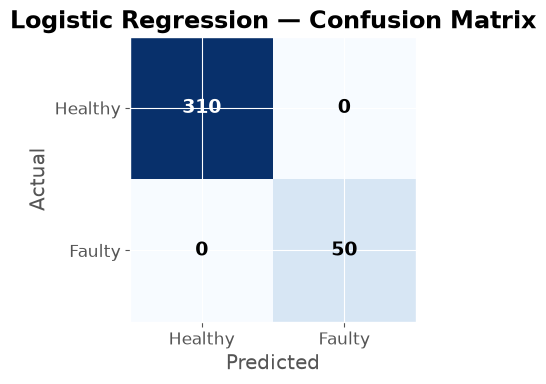

In [64]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_lr, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Healthy', 'Faulty'])
ax.set_yticklabels(['Healthy', 'Faulty'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Logistic Regression — Confusion Matrix', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_lr[i,j], ha='center', va='center', 
                fontsize=14, fontweight='bold',
                color='white' if cm_lr[i,j] > cm_lr.max()/2 else 'black')
plt.tight_layout()
plt.show()

## Random Forest

In [65]:

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [66]:
print(f"  Accuracy : {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Healthy', 'Faulty']))


  Accuracy : 100.00%

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       310
      Faulty       1.00      1.00      1.00        50

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



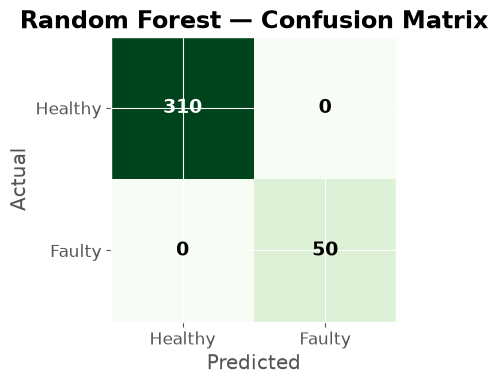

In [67]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_rf, cmap='Greens')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Healthy', 'Faulty'])
ax.set_yticklabels(['Healthy', 'Faulty'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_rf[i,j], ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm_rf[i,j] > cm_rf.max()/2 else 'black')
plt.tight_layout()
plt.show()

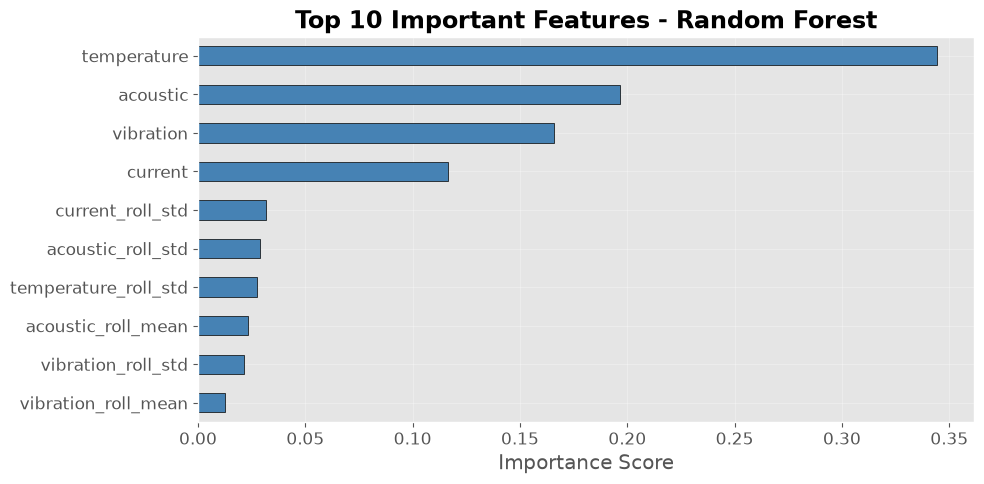

In [69]:
feat_imp = pd.Series(rf_model.feature_importances_, index=clf_features)
top10 = feat_imp.nlargest(10)

fig, ax = plt.subplots(figsize=(10, 5))
top10.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 10 Important Features - Random Forest', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Classification Results

| Model | Accuracy | Precision | Recall | F1-Score |
|-------|----------|-----------|--------|----------|
| Logistic Regression | 100% | 1.00 | 1.00 | 1.00 |
| Random Forest | 100% | 1.00 | 1.00 | 1.00 |

### Why 100% Accuracy?
This dataset is **simulated**, meaning Healthy and Faulty sensor
readings are clearly separated by design (vibration-label
correlation = 0.92). Both models perfectly learned the boundary.

### Methodology is still valid:
- Used **TimeSeriesSplit** to prevent data leakage
- Used **class_weight='balanced'** for imbalanced data
- Used **StandardScaler** for feature normalization
- Used **rolling features + lag features** for time-series context

In real-world IoT data, sensor noise and overlap would make
this a much harder problem.

## Save model

In [70]:
# Save trained models

import pickle
import os

# Save folder
save_dir = r'E:\Time serise noyase data analysis\Time_serise_Noice_dataset_analysis\models'
os.makedirs(save_dir, exist_ok=True)

# Models save 
with open(os.path.join(save_dir, 'logistic_regression.pkl'), 'wb') as f:
    pickle.dump(lr_model, f)

with open(os.path.join(save_dir, 'random_forest.pkl'), 'wb') as f:
    pickle.dump(rf_model, f)

# Scaler save 
with open(os.path.join(save_dir, 'scaler_clf.pkl'), 'wb') as f:
    pickle.dump(scaler_clf, f)

# Feature list save 
with open(os.path.join(save_dir, 'clf_features.pkl'), 'wb') as f:
    pickle.dump(clf_features, f)

print("Models saved successfully!")
print(f"     Location: {save_dir}")
print(f"   → logistic_regression.pkl")
print(f"   → random_forest.pkl")
print(f"   → scaler_clf.pkl")
print(f"   → clf_features.pkl")

Models saved successfully!
     Location: E:\Time serise noyase data analysis\Time_serise_Noice_dataset_analysis\models
   → logistic_regression.pkl
   → random_forest.pkl
   → scaler_clf.pkl
   → clf_features.pkl


In [71]:
# Test with normal (manually created) sensor data

import pickle
import numpy as np
import pandas as pd



In [74]:
# Load models and scaler
save_dir = r'E:\Time serise noyase data analysis\Time_serise_Noice_dataset_analysis\models'

with open(os.path.join(save_dir, 'logistic_regression.pkl'), 'rb') as f:
    lr_loaded = pickle.load(f)

with open(os.path.join(save_dir, 'random_forest.pkl'), 'rb') as f:
    rf_loaded = pickle.load(f)

with open(os.path.join(save_dir, 'scaler_clf.pkl'), 'rb') as f:
    scaler_loaded = pickle.load(f)

with open(os.path.join(save_dir, 'clf_features.pkl'), 'rb') as f:
    features_loaded = pickle.load(f)

In [75]:
# Normal healthy machine reading
normal_data = {
    'vibration': 0.80,       # normal range
    'acoustic': 0.61,        # normal range
    'temperature': 65.0,     # normal °C
    'current': 12.0,         # normal amps
    'IMF_1': 0.17,
    'vibration_roll_mean': 0.80,
    'vibration_roll_std': 0.01,
    'vibration_lag1': 0.79,
    'acoustic_roll_mean': 0.61,
    'acoustic_roll_std': 0.01,
    'acoustic_lag1': 0.60,
    'temperature_roll_mean': 65.0,
    'temperature_roll_std': 0.5,
    'temperature_lag1': 64.8,
    'current_roll_mean': 12.0,
    'current_roll_std': 0.1,
    'current_lag1': 11.9,
    'IMF_1_roll_mean': 0.17,
    'IMF_1_roll_std': 0.01,
    'IMF_1_lag1': 0.16,
    'hour': 10,
    'machine_enc': 0          # M01
}

# Faulty machine reading
faulty_data = {
    'vibration': 1.35,        # high — fault!
    'acoustic': 0.95,         # high — fault!
    'temperature': 80.0,      # high — fault!
    'current': 15.5,          # high — fault!
    'IMF_1': 0.35,
    'vibration_roll_mean': 1.30,
    'vibration_roll_std': 0.08,
    'vibration_lag1': 1.28,
    'acoustic_roll_mean': 0.92,
    'acoustic_roll_std': 0.05,
    'acoustic_lag1': 0.90,
    'temperature_roll_mean': 79.0,
    'temperature_roll_std': 1.2,
    'temperature_lag1': 78.5,
    'current_roll_mean': 15.2,
    'current_roll_std': 0.3,
    'current_lag1': 15.0,
    'IMF_1_roll_mean': 0.33,
    'IMF_1_roll_std': 0.02,
    'IMF_1_lag1': 0.32,
    'hour': 14,
    'machine_enc': 0           # M01
}

In [76]:
test_cases = [
    ("Normal Machine", normal_data),
    ("Faulty Machine", faulty_data)
]

In [77]:
for label, data in test_cases:
    df_input = pd.DataFrame([data])[features_loaded]
    scaled   = scaler_loaded.transform(df_input)

    pred_lr = lr_loaded.predict(scaled)[0]
    pred_rf = rf_loaded.predict(scaled)[0]

    prob_lr = lr_loaded.predict_proba(scaled)[0][1] * 100
    prob_rf = rf_loaded.predict_proba(scaled)[0][1] * 100

    result_lr = "FAULTY" if pred_lr == 1 else "HEALTHY"
    result_rf = "FAULTY" if pred_rf == 1 else "HEALTHY"

    print(f"\n  Input: {label}")
    print(f"  ├─ Logistic Regression : {result_lr} (Fault probability: {prob_lr:.1f}%)")
    print(f"  └─ Random Forest       : {result_rf} (Fault probability: {prob_rf:.1f}%)")



  Input: Normal Machine
  ├─ Logistic Regression : HEALTHY (Fault probability: 0.0%)
  └─ Random Forest       : HEALTHY (Fault probability: 0.0%)

  Input: Faulty Machine
  ├─ Logistic Regression : FAULTY (Fault probability: 100.0%)
  └─ Random Forest       : FAULTY (Fault probability: 79.0%)


In [78]:
# Save all processed datasets

import os
import pandas as pd

data_processed_dir = r'E:\Time serise noyase data analysis\Time_serise_Noice_dataset_analysis\data\processed'
os.makedirs(data_processed_dir, exist_ok=True)

df_clean.to_csv(os.path.join(data_processed_dir, 'df_clean.csv'), index=False)

df_feat.to_csv(os.path.join(data_processed_dir, 'df_feat.csv'), index=False)

pd.DataFrame(X_train, columns=clf_features).to_csv(
    os.path.join(data_processed_dir, 'X_train.csv'), index=False)

pd.DataFrame(X_test, columns=clf_features).to_csv(
    os.path.join(data_processed_dir, 'X_test.csv'), index=False)

y_train.to_csv(os.path.join(data_processed_dir, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(data_processed_dir, 'y_test.csv'), index=False)


print("All processed datasets saved!")
print(f"\n   Location: {data_processed_dir}")
print(f"   → df_clean.csv       ({df_clean.shape[0]} rows × {df_clean.shape[1]} cols)")
print(f"   → df_feat.csv        ({df_feat.shape[0]} rows × {df_feat.shape[1]} cols)")
print(f"   → X_train.csv        ({len(X_train)} rows × {len(clf_features)} cols)")
print(f"   → X_test.csv         ({len(X_test)} rows × {len(clf_features)} cols)")
print(f"   → y_train.csv        ({len(y_train)} rows)")
print(f"   → y_test.csv         ({len(y_test)} rows)")

All processed datasets saved!

   Location: E:\Time serise noyase data analysis\Time_serise_Noice_dataset_analysis\data\processed
   → df_clean.csv       (1800 rows × 10 cols)
   → df_feat.csv        (1800 rows × 27 cols)
   → X_train.csv        (1440 rows × 22 cols)
   → X_test.csv         (360 rows × 22 cols)
   → y_train.csv        (1440 rows)
   → y_test.csv         (360 rows)
